# EventBridge vs Notifications API — Latency Comparison

Head-to-head comparison of **Genesys Notifications API (WebSocket)** and **EventBridge (SQS)** transcription delivery latency, using **poc-deepgram** as ground-truth audio clock.

## What We're Comparing

Both delivery paths share Stages 1–3 (audio capture → STT → endpointing). The difference is Stage 4:

```
Notifications API (WebSocket):
Speaker → [1] Audio Capture → [2] r2d2 STT → [3] Endpointing
  → [4a] WebSocket push to notifications-spike

EventBridge (SQS):
Speaker → [1] Audio Capture → [2] r2d2 STT → [3] Endpointing
  → [4b-i] EB publish → [4b-ii] EB rule → SQS enqueue → [4b-iii] Consumer polls
```

## Formula

```
true_latency = receivedAt - deepgram_audio_wall_clock_end
```

Where `receivedAt` is from notifications-spike (WebSocket) or sqs_consumer (SQS poll), and `deepgram_audio_wall_clock_end` is the ground-truth wall-clock time from poc-deepgram.

See `docs/eventbridge_comparison_plan.md` for the full implementation plan.

---
## Module 1: Setup & Configuration

In [1]:
import json
import statistics
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from scripts.correlate_latency import (
    correlate,
    correlate_eventbridge,
    export_csv,
    load_deepgram_session,
    load_genesys_conversation,
    load_eventbridge_conversation,
    match_utterances,
    compute_latency,
    CorrelationResult,
)

# === DIRECTORIES ===
DEEPGRAM_RESULTS_DIR = (REPO_ROOT / ".." / "poc-deepgram" / "results").resolve()
NOTIF_EVENTS_DIR = (REPO_ROOT / "conversation_events").resolve()
EB_EVENTS_DIR = (REPO_ROOT / "EventBridge" / "conversation_events").resolve()

OUTPUT_DIR = REPO_ROOT / "analysis_results" / "cross_system_eb"
SAVE_DPI = 300
SIMILARITY_THRESHOLD = 0.55
NUM_RECENT = 6  # Number of most recent sessions to correlate

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root: {REPO_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Deepgram results: {DEEPGRAM_RESULTS_DIR}")
print(f"Notifications events: {NOTIF_EVENTS_DIR}")
print(f"EventBridge events: {EB_EVENTS_DIR}")

Repo root: /Users/xnxn040/PycharmProjects/notifications-spike
Output dir: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system_eb
Deepgram results: /Users/xnxn040/PycharmProjects/poc-deepgram/results
Notifications events: /Users/xnxn040/PycharmProjects/notifications-spike/conversation_events
EventBridge events: /Users/xnxn040/PycharmProjects/notifications-spike/EventBridge/conversation_events


---
## Module 2: Load & Auto-Match Files

Match files from all 3 sources:
- **Deepgram ↔ Notifications**: by overlapping time windows
- **Deepgram ↔ EventBridge**: by overlapping time windows
- **Notifications ↔ EventBridge**: by conversation ID (same UUID in both directories)

In [2]:
# List available files from all 3 systems
dg_files = sorted(DEEPGRAM_RESULTS_DIR.glob("*.json"), key=lambda f: f.stat().st_mtime, reverse=True)
notif_files = sorted(NOTIF_EVENTS_DIR.glob("*.jsonl"), key=lambda f: f.stat().st_mtime, reverse=True)
eb_files = sorted(EB_EVENTS_DIR.glob("*.jsonl"), key=lambda f: f.stat().st_mtime, reverse=True)

print(f"Available Deepgram sessions: {len(dg_files)}")
for i, f in enumerate(dg_files[:NUM_RECENT + 2]):
    data = json.loads(f.read_text())
    session = data.get("session", {})
    print(f"  [{i}] {f.name}  ({session.get('started_at', '?')} — {session.get('duration_seconds', '?')}s)")

print(f"\nAvailable Notifications conversations: {len(notif_files)}")
for i, f in enumerate(notif_files[:NUM_RECENT + 2]):
    lines = f.read_text().strip().splitlines()
    if lines:
        first = json.loads(lines[0])
        ts = datetime.fromtimestamp(first["receivedAt"], tz=timezone.utc)
        print(f"  [{i}] {f.name}  ({ts:%Y-%m-%d %H:%M} — {len(lines)} events)")

print(f"\nAvailable EventBridge conversations: {len(eb_files)}")
for i, f in enumerate(eb_files[:NUM_RECENT + 2]):
    lines = f.read_text().strip().splitlines()
    if lines:
        first = json.loads(lines[0])
        ts = datetime.fromtimestamp(first["receivedAt"], tz=timezone.utc)
        print(f"  [{i}] {f.name}  ({ts:%Y-%m-%d %H:%M} — {len(lines)} events)")

Available Deepgram sessions: 1
  [0] nova-3_2026-03-21T00-40-56Z.json  (2026-03-21T00:40:56.974453+00:00 — 118.4s)

Available Notifications conversations: 1
  [0] a9708b9e-39fb-4de9-8060-d8bdda444a5d.jsonl  (2026-03-21 00:40 — 13 events)

Available EventBridge conversations: 1
  [0] a9708b9e-39fb-4de9-8060-d8bdda444a5d.jsonl  (2026-03-21 00:40 — 13 events)


In [3]:
def get_dg_time_range(path):
    """Extract session start/end times from a Deepgram session JSON."""
    data = json.loads(path.read_text())
    session = data.get("session", {})
    started = session.get("started_at", "")
    ended = session.get("ended_at", "")
    start_ts = datetime.fromisoformat(started).timestamp() if started else 0
    end_ts = datetime.fromisoformat(ended).timestamp() if ended else float("inf")
    return start_ts, end_ts


def get_jsonl_time_range(path):
    """Extract first/last receivedAt from a JSONL file."""
    lines = path.read_text().strip().splitlines()
    if not lines:
        return 0, 0
    timestamps = [json.loads(line)["receivedAt"] for line in lines]
    return min(timestamps), max(timestamps)


# Take the N most recent files
dg_recent = dg_files[:NUM_RECENT]
notif_recent = notif_files[:NUM_RECENT]
eb_recent = eb_files[:NUM_RECENT]

# Match Deepgram ↔ Notifications by time overlap
notif_matched = []
used_notif = set()
for dg_path in dg_recent:
    dg_start, dg_end = get_dg_time_range(dg_path)
    best_idx, best_overlap = None, 0
    for j, nf in enumerate(notif_recent):
        if j in used_notif:
            continue
        nf_start, nf_end = get_jsonl_time_range(nf)
        overlap = max(0, min(dg_end, nf_end) - max(dg_start, nf_start))
        if overlap > best_overlap:
            best_overlap = overlap
            best_idx = j
    if best_idx is not None:
        notif_matched.append((dg_path, notif_recent[best_idx]))
        used_notif.add(best_idx)

# Match Notifications ↔ EventBridge by conversation ID
eb_by_conv_id = {f.stem: f for f in eb_recent}

# Build triple matches: (deepgram, notifications, eventbridge)
triple_matched = []
for dg_path, notif_path in notif_matched:
    conv_id = notif_path.stem
    eb_path = eb_by_conv_id.get(conv_id)
    triple_matched.append((dg_path, notif_path, eb_path))

print(f"\nMatched {len(triple_matched)} session triple(s):")
for dg_p, nf_p, eb_p in triple_matched:
    eb_status = eb_p.name if eb_p else "MISSING"
    print(f"  DG: {dg_p.name}")
    print(f"    Notif: {nf_p.name}")
    print(f"    EB:    {eb_status}")

# --- EB-only pairs: EB files with no Notifications counterpart ---
# These are conversations where the agent never connected, so notifications-spike
# never subscribed to the transcription topic. EventBridge captures all
# transcriptions org-wide regardless of agent connection state.
triple_eb_stems = {eb_p.stem for _, _, eb_p in triple_matched if eb_p}

eb_only_matched = []
used_dg_for_eb_only = set()
for eb_path in eb_recent:
    if eb_path.stem in triple_eb_stems:
        continue
    # Match this EB file to a Deepgram session by time overlap
    eb_start, eb_end = get_jsonl_time_range(eb_path)
    best_dg, best_overlap = None, 0
    for dg_path in dg_recent:
        if dg_path in used_dg_for_eb_only:
            continue
        dg_start, dg_end = get_dg_time_range(dg_path)
        overlap = max(0, min(dg_end, eb_end) - max(dg_start, eb_start))
        if overlap > best_overlap:
            best_overlap = overlap
            best_dg = dg_path
    if best_dg is not None:
        eb_only_matched.append((best_dg, eb_path))
        used_dg_for_eb_only.add(best_dg)

if eb_only_matched:
    print(f"\nEB-only pairs (no Notifications counterpart): {len(eb_only_matched)}")
    for dg_p, eb_p in eb_only_matched:
        print(f"  DG: {dg_p.name}")
        print(f"    EB: {eb_p.name}")
    print("  Note: Agent never connected on these calls — notifications-spike did not")
    print("  subscribe. EventBridge captured them org-wide.")


Matched 1 session triple(s):
  DG: nova-3_2026-03-21T00-40-56Z.json
    Notif: a9708b9e-39fb-4de9-8060-d8bdda444a5d.jsonl
    EB:    a9708b9e-39fb-4de9-8060-d8bdda444a5d.jsonl


---
## Module 2.5: Data Quality Validation

Verify both delivery paths captured the same conversations with similar event counts.

In [4]:
print("DATA QUALITY CHECK")
print("=" * 70)

quality_issues = []

for dg_p, nf_p, eb_p in triple_matched:
    conv_id = nf_p.stem
    print(f"\nConversation: {conv_id}")

    # Count Notifications events
    nf_lines = nf_p.read_text().strip().splitlines()
    nf_total = len(nf_lines)
    nf_final = sum(
        1 for line in nf_lines
        if json.loads(line).get("transcript", {}).get("isFinal", False)
    )

    # Count EventBridge events
    if eb_p and eb_p.exists():
        eb_lines = eb_p.read_text().strip().splitlines()
        eb_total = len(eb_lines)
        eb_final = 0
        for line in eb_lines:
            raw = json.loads(line)
            for t in raw.get("transcripts", []):
                if t.get("isFinal", False):
                    eb_final += 1
        print(f"  Notifications: {nf_total} total events, {nf_final} isFinal")
        print(f"  EventBridge:   {eb_total} total events, {eb_final} isFinal")

        if abs(nf_final - eb_final) > max(2, nf_final * 0.2):
            msg = f"  ⚠️  isFinal count mismatch: Notif={nf_final}, EB={eb_final}"
            print(msg)
            quality_issues.append(msg)
        else:
            print(f"  ✓ Event counts are consistent")
    else:
        msg = f"  ⚠️  EventBridge data MISSING for {conv_id}"
        print(msg)
        quality_issues.append(msg)

if quality_issues:
    print(f"\n{'!' * 70}")
    print(f"WARNING: {len(quality_issues)} quality issue(s) detected.")
    for issue in quality_issues:
        print(issue)
    print(f"{'!' * 70}")
else:
    print(f"\n✓ All conversations have consistent data across both paths.")

DATA QUALITY CHECK

Conversation: a9708b9e-39fb-4de9-8060-d8bdda444a5d
  Notifications: 13 total events, 13 isFinal
  EventBridge:   13 total events, 13 isFinal
  ✓ Event counts are consistent

✓ All conversations have consistent data across both paths.


---
## Module 3: Correlate Both Paths with Deepgram Ground Truth

In [ ]:
# --- Data file existence verification ---
print("DATA FILE VERIFICATION")
print("=" * 70)
dg_exist = [f for f in dg_recent if f.exists()]
notif_exist = [f for f in notif_recent if f.exists()]
eb_exist = [f for f in eb_recent if f.exists()]
print(f"  Deepgram files:      {len(dg_exist)}/{len(dg_recent)} exist")
print(f"  Notifications files: {len(notif_exist)}/{len(notif_recent)} exist")
print(f"  EventBridge files:   {len(eb_exist)}/{len(eb_recent)} exist")

# Spot-check first Deepgram file for audio_wall_clock_end
if dg_exist:
    spot_data = json.loads(dg_exist[0].read_text())
    spot_transcripts = spot_data.get("transcripts", [])
    has_awce = any(t.get("audio_wall_clock_end") is not None for t in spot_transcripts)
    print(f"\n  Deepgram audio_wall_clock_end check ({dg_exist[0].name}):")
    print(f"    Transcripts: {len(spot_transcripts)}, has audio_wall_clock_end: {has_awce}")
    if not has_awce:
        print("    ⚠️  WARNING: audio_wall_clock_end missing — correlations will return 0 matches!")

missing = []
if len(dg_exist) != len(dg_recent):
    missing.extend([f for f in dg_recent if not f.exists()])
if len(notif_exist) != len(notif_recent):
    missing.extend([f for f in notif_recent if not f.exists()])
if len(eb_exist) != len(eb_recent):
    missing.extend([f for f in eb_recent if not f.exists()])
if missing:
    print(f"\n  ⚠️  Missing files:")
    for m in missing:
        print(f"    {m}")
else:
    print("\n  ✓ All expected data files exist on disk.")

# --- Correlate Notifications path ---
print("\n\nNOTIFICATIONS CORRELATION")
print("=" * 70)
notif_results = []
for dg_path, nf_path, eb_path in triple_matched:
    pair_results = correlate(dg_path, nf_path, similarity_threshold=SIMILARITY_THRESHOLD)
    notif_results.extend(pair_results)
    status = f"{len(pair_results)} matched"
    if len(pair_results) == 0:
        # Diagnostics: load separately to identify why
        dg_transcripts = load_deepgram_session(dg_path)
        nf_events = load_genesys_conversation(nf_path)
        status += (f" — DG has {len(dg_transcripts)} transcripts, "
                   f"Notif has {len(nf_events)} events")
        if dg_transcripts:
            awce = dg_transcripts[0].audio_wall_clock_end
            status += f" (first DG audio_wall_clock_end={'present' if awce else 'MISSING'})"
    print(f"  {dg_path.name} <-> {nf_path.name}: {status}")

# --- Correlate EventBridge path (triple matches) ---
print("\n\nEVENTBRIDGE CORRELATION")
print("=" * 70)
eb_results = []
for dg_path, nf_path, eb_path in triple_matched:
    if eb_path and eb_path.exists():
        pair_results = correlate_eventbridge(
            dg_path, eb_path, similarity_threshold=SIMILARITY_THRESHOLD
        )
        eb_results.extend(pair_results)
        status = f"{len(pair_results)} matched"
        if len(pair_results) == 0:
            dg_transcripts = load_deepgram_session(dg_path)
            eb_events = load_eventbridge_conversation(eb_path)
            status += (f" — DG has {len(dg_transcripts)} transcripts, "
                       f"EB has {len(eb_events)} events")
        print(f"  {dg_path.name} <-> {eb_path.name}: {status}")
    else:
        print(f"  {dg_path.name} — SKIPPED (no EB data)")

# --- Correlate EB-only pairs (no Notifications counterpart) ---
if eb_only_matched:
    print(f"\n  EB-only pairs:")
    for dg_path, eb_path in eb_only_matched:
        pair_results = correlate_eventbridge(
            dg_path, eb_path, similarity_threshold=SIMILARITY_THRESHOLD
        )
        eb_results.extend(pair_results)
        status = f"{len(pair_results)} matched"
        if len(pair_results) == 0:
            dg_transcripts = load_deepgram_session(dg_path)
            eb_events = load_eventbridge_conversation(eb_path)
            status += (f" — DG has {len(dg_transcripts)} transcripts, "
                       f"EB has {len(eb_events)} events")
        print(f"  {dg_path.name} <-> {eb_path.name}: {status}")

print(f"\nTotal Notifications matched pairs: {len(notif_results)}")
print(f"Total EventBridge matched pairs:   {len(eb_results)}")

# Build DataFrames
def results_to_df(results, source_label):
    if not results:
        return pd.DataFrame()
    rows = [
        {
            "source": source_label,
            "deepgram_transcript": r.deepgram_transcript,
            "genesys_transcript": r.genesys_transcript,
            "audio_wall_clock_end": r.audio_wall_clock_end,
            "genesys_received_at": r.genesys_received_at,
            "true_latency_s": r.true_latency_s,
            "true_latency_ms": r.true_latency_ms,
            "channel": r.channel,
            "similarity": r.similarity,
            "deepgram_confidence": r.deepgram_confidence,
            "genesys_confidence": r.genesys_confidence,
        }
        for r in results
    ]
    df = pd.DataFrame(rows)
    df["received_dt"] = pd.to_datetime(df["genesys_received_at"], unit="s", utc=True)
    df["audio_dt"] = pd.to_datetime(df["audio_wall_clock_end"], unit="s", utc=True)
    return df

df_notif = results_to_df(notif_results, "Notifications")
df_eb = results_to_df(eb_results, "EventBridge")

# --- False-match filter: exclude negative latency ---
for label, df in [("Notifications", df_notif), ("EventBridge", df_eb)]:
    if not df.empty:
        neg_count = (df["true_latency_ms"] < 0).sum()
        if neg_count > 0:
            print(f"\n⚠️  Filtering {neg_count} false matches with negative latency from {label}")

df_notif = df_notif[df_notif["true_latency_ms"] >= 0] if not df_notif.empty else df_notif
df_eb = df_eb[df_eb["true_latency_ms"] >= 0] if not df_eb.empty else df_eb

df_all = pd.concat([df_notif, df_eb], ignore_index=True)

print(f"\nNotifications DataFrame: {len(df_notif)} rows")
print(f"EventBridge DataFrame:   {len(df_eb)} rows")

---
## Module 4: Summary Statistics (per path)

In [6]:
def print_latency_summary(df, label):
    """Print summary statistics for a single delivery path."""
    if df.empty:
        print(f"\n{label}: No data")
        return
    lat = df["true_latency_ms"]
    print(f"\n{'=' * 60}")
    print(f"{label} — LATENCY SUMMARY")
    print(f"{'=' * 60}")
    print(f"  Matched pairs:    {len(df)}")
    print(f"  Mean latency:     {lat.mean():.0f} ms")
    print(f"  Median latency:   {lat.median():.0f} ms")
    print(f"  Std deviation:    {lat.std():.0f} ms")
    print(f"  Min latency:      {lat.min():.0f} ms")
    print(f"  Max latency:      {lat.max():.0f} ms")
    print()
    for p in [0.50, 0.75, 0.90, 0.95, 0.99]:
        print(f"  p{int(p*100):02d}:             {lat.quantile(p):.0f} ms")
    channels = df["channel"].unique()
    if len(channels) > 1:
        print(f"\n  By Channel:")
        for ch in sorted(channels):
            ch_data = df[df["channel"] == ch]["true_latency_ms"]
            print(f"    {ch}: median={ch_data.median():.0f}ms, mean={ch_data.mean():.0f}ms, n={len(ch_data)}")


print_latency_summary(df_notif, "Notifications API (WebSocket)")
print_latency_summary(df_eb, "EventBridge (SQS)")


Notifications API (WebSocket) — LATENCY SUMMARY
  Matched pairs:    10
  Mean latency:     4207 ms
  Median latency:   3425 ms
  Std deviation:    2701 ms
  Min latency:      1091 ms
  Max latency:      9416 ms

  p50:             3425 ms
  p75:             6201 ms
  p90:             6839 ms
  p95:             8128 ms
  p99:             9159 ms

EventBridge (SQS) — LATENCY SUMMARY
  Matched pairs:    10
  Mean latency:     4402 ms
  Median latency:   3669 ms
  Std deviation:    2679 ms
  Min latency:      1323 ms
  Max latency:      9548 ms

  p50:             3669 ms
  p75:             6384 ms
  p90:             7057 ms
  p95:             8302 ms
  p99:             9299 ms


---
## Module 4.5: Self-Reported Latency (Anchor-Event Method)

Recompute Genesys self-reported latency for the same 6 calls using the anchor-event method from `latency_analysis-01-RESULTS.ipynb`. This method is **delivery-path-independent** — the constant delivery overhead cancels out via the anchor event.

```
conversation_start = min(receivedAt - (offsetMs + durationMs) / 1000)  across all events
latency = receivedAt - (conversation_start + (offsetMs + durationMs) / 1000)
```

In [ ]:
def calculate_conversation_latency(events):
    """Calculate self-reported latency for a list of Notifications JSONL events.

    Uses the anchor-event method: the event with the smallest
    (receivedAt - audio_end_offset) defines conversation_start, and all
    other events' latency is measured relative to that anchor.

    Returns list of dicts with latency info, or empty list if < 2 events.
    """
    final_events = []
    for event in events:
        t = event.get("transcript", {})
        if not t.get("isFinal", False):
            continue
        alts = t.get("alternatives", [])
        if not alts:
            continue
        alt = alts[0]
        offset_ms = alt.get("offsetMs", 0)
        duration_ms = alt.get("durationMs", 0)
        received_at = event["receivedAt"]
        audio_end_s = (offset_ms + duration_ms) / 1000.0
        final_events.append({
            "receivedAt": received_at,
            "audio_end_s": audio_end_s,
            "transcript": alt.get("transcript", ""),
            "channel": t.get("channel", "UNKNOWN"),
            "offsetMs": offset_ms,
            "durationMs": duration_ms,
        })

    if len(final_events) < 2:
        return []

    # Anchor: event that minimizes (receivedAt - audio_end_s)
    conversation_start = min(e["receivedAt"] - e["audio_end_s"] for e in final_events)

    results = []
    for e in final_events:
        expected_arrival = conversation_start + e["audio_end_s"]
        latency_s = e["receivedAt"] - expected_arrival
        results.append({
            "latency_s": latency_s,
            "latency_ms": latency_s * 1000,
            "transcript": e["transcript"],
            "channel": e["channel"],
        })
    return results


def calculate_eb_conversation_latency(events):
    """Calculate self-reported latency for EventBridge SQS consumer JSONL events.

    Same anchor-event method as Notifications, but EB format has a top-level
    ``transcripts[]`` array (one SQS message can carry multiple utterances)
    instead of Notifications' singular ``transcript`` object.
    """
    final_events = []
    for event in events:
        received_at = event["receivedAt"]
        for t in event.get("transcripts", []):
            if not t.get("isFinal", False):
                continue
            alts = t.get("alternatives", [])
            if not alts:
                continue
            alt = alts[0]
            offset_ms = alt.get("offsetMs", 0)
            duration_ms = alt.get("durationMs", 0)
            audio_end_s = (offset_ms + duration_ms) / 1000.0
            final_events.append({
                "receivedAt": received_at,
                "audio_end_s": audio_end_s,
                "transcript": alt.get("transcript", ""),
                "channel": t.get("channel", "UNKNOWN"),
            })

    if len(final_events) < 2:
        return []

    conversation_start = min(e["receivedAt"] - e["audio_end_s"] for e in final_events)

    results = []
    for e in final_events:
        expected_arrival = conversation_start + e["audio_end_s"]
        latency_s = e["receivedAt"] - expected_arrival
        results.append({
            "latency_s": latency_s,
            "latency_ms": latency_s * 1000,
            "transcript": e["transcript"],
            "channel": e["channel"],
        })
    return results


# Compute self-reported latency for the Notifications data
self_reported_all = []
for _, nf_path, _ in triple_matched:
    lines = nf_path.read_text().strip().splitlines()
    events = [json.loads(line) for line in lines if line.strip()]
    conv_latencies = calculate_conversation_latency(events)
    self_reported_all.extend(conv_latencies)
    if conv_latencies:
        meds = statistics.median([r["latency_ms"] for r in conv_latencies])
        print(f"  Notif {nf_path.stem}: {len(conv_latencies)} utterances, median {meds:.0f}ms")

if self_reported_all:
    sr_latencies_ms = [r["latency_ms"] for r in self_reported_all]
    print(f"\nNotif Self-Reported Summary (anchor-event method, {len(sr_latencies_ms)} utterances):")
    print(f"  Median: {statistics.median(sr_latencies_ms):.0f} ms")
    print(f"  Mean:   {statistics.mean(sr_latencies_ms):.0f} ms")
    if len(sr_latencies_ms) >= 20:
        sorted_sr = sorted(sr_latencies_ms)
        p95_idx = int(len(sorted_sr) * 0.95)
        p99_idx = int(len(sorted_sr) * 0.99)
        print(f"  p95:    {sorted_sr[p95_idx]:.0f} ms")
        print(f"  p99:    {sorted_sr[p99_idx]:.0f} ms")
else:
    sr_latencies_ms = []
    print("No Notifications self-reported latency data (need ≥2 isFinal events per conversation).")

# Compute self-reported latency for EventBridge data
eb_self_reported_all = []
all_eb_sr_paths = [eb_p for _, _, eb_p in triple_matched if eb_p and eb_p.exists()]
all_eb_sr_paths.extend(eb_p for _, eb_p in eb_only_matched if eb_p.exists())

for eb_path in all_eb_sr_paths:
    lines = eb_path.read_text().strip().splitlines()
    events = [json.loads(line) for line in lines if line.strip()]
    conv_latencies = calculate_eb_conversation_latency(events)
    eb_self_reported_all.extend(conv_latencies)
    if conv_latencies:
        meds = statistics.median([r["latency_ms"] for r in conv_latencies])
        print(f"  EB {eb_path.stem}: {len(conv_latencies)} utterances, median {meds:.0f}ms")

if eb_self_reported_all:
    eb_sr_latencies_ms = [r["latency_ms"] for r in eb_self_reported_all]
    print(f"\nEB Self-Reported Summary (anchor-event method, {len(eb_sr_latencies_ms)} utterances):")
    print(f"  Median: {statistics.median(eb_sr_latencies_ms):.0f} ms")
    print(f"  Mean:   {statistics.mean(eb_sr_latencies_ms):.0f} ms")
    if len(eb_sr_latencies_ms) >= 20:
        sorted_eb_sr = sorted(eb_sr_latencies_ms)
        p95_idx = int(len(sorted_eb_sr) * 0.95)
        p99_idx = int(len(sorted_eb_sr) * 0.99)
        print(f"  p95:    {sorted_eb_sr[p95_idx]:.0f} ms")
        print(f"  p99:    {sorted_eb_sr[p99_idx]:.0f} ms")
else:
    eb_sr_latencies_ms = []
    print("No EventBridge self-reported latency data (need ≥2 isFinal events per conversation).")

---
## Module 5: Head-to-Head Comparison Table

The key deliverable. Five rows comparing delivery mechanisms:

| Row | What It Measures | Formula |
|-----|------------------|---------|
| **Notifications API** | True end-to-end via WebSocket | `notif_receivedAt - deepgram_audio_end` |
| **EventBridge (SQS)** | True end-to-end via EB→SQS | `eb_receivedAt - deepgram_audio_end` |
| **Notif Self-Reported** | Internal processing (anchor-relative) via Notifications | anchor-event method |
| **EB Self-Reported** | Internal processing (anchor-relative) via EventBridge | anchor-event method |
| **Deepgram/Audio Hook** | Deepgram Nova-3 STT latency (reference) | `server_receipt_time - audio_end` |

In [ ]:
def compute_stats(values_ms):
    """Compute summary stats for a list of latency values in ms."""
    if not values_ms:
        return {k: float("nan") for k in ["median", "mean", "p95", "p99", "min", "max", "n"]}
    s = sorted(values_ms)
    n = len(s)
    return {
        "median": statistics.median(s),
        "mean": statistics.mean(s),
        "p95": s[int(n * 0.95)] if n >= 20 else s[-1],
        "p99": s[int(n * 0.99)] if n >= 100 else s[-1],
        "min": s[0],
        "max": s[-1],
        "n": n,
    }


# Deepgram/Audio Hook latency — matched utterances only
# Build lookup from raw Deepgram data: audio_wall_clock_end → full transcript dict
# This ensures we compare the SAME utterances across all systems.
dg_transcript_lookup = {}  # {audio_wall_clock_end: transcript_dict}
for dg_path, _, _ in triple_matched:
    data = json.loads(dg_path.read_text())
    for t in data.get("transcripts", []):
        wc_end = t.get("audio_wall_clock_end")
        if wc_end is not None and t.get("latency_ms") is not None:
            dg_transcript_lookup[wc_end] = t

# Collect Deepgram latency only for utterances that matched in the correlation
matched_awce = set()
if not df_notif.empty:
    matched_awce.update(df_notif["audio_wall_clock_end"].tolist())
if not df_eb.empty:
    matched_awce.update(df_eb["audio_wall_clock_end"].tolist())

dg_matched = {awce: dg_transcript_lookup[awce]
              for awce in matched_awce if awce in dg_transcript_lookup}
dg_latencies_ms = [t["latency_ms"] for t in dg_matched.values()]

# Build df_dg for visualizations — same structure as df_notif / df_eb
dg_rows = []
for awce, t in dg_matched.items():
    dg_rows.append({
        "source": "Deepgram",
        "deepgram_transcript": t.get("transcript", ""),
        "genesys_transcript": "",
        "audio_wall_clock_end": awce,
        "genesys_received_at": t.get("server_receipt_time", 0),
        "true_latency_s": t["latency_ms"] / 1000.0,
        "true_latency_ms": t["latency_ms"],
        "channel": "",
        "similarity": 0.0,
        "deepgram_confidence": t.get("confidence", 0.0),
        "genesys_confidence": 0.0,
    })
df_dg = pd.DataFrame(dg_rows)
if not df_dg.empty:
    df_dg["received_dt"] = pd.to_datetime(df_dg["genesys_received_at"], unit="s", utc=True)
    df_dg["audio_dt"] = pd.to_datetime(df_dg["audio_wall_clock_end"], unit="s", utc=True)

# Rebuild df_all to include Deepgram as a competing source
df_all = pd.concat([df_notif, df_eb, df_dg], ignore_index=True)

if dg_latencies_ms:
    print(f"Deepgram latency: {len(dg_latencies_ms)} matched utterances "
          f"(out of {len(dg_transcript_lookup)} total in session files)")
    print(f"  Excluded {len(dg_transcript_lookup) - len(dg_latencies_ms)} unmatched "
          f"utterances (including cold-start / short fragments)")
else:
    print("No Deepgram latency data for matched utterances.")

# Build comparison rows
rows = {
    "Notifications API (WebSocket)": compute_stats(df_notif["true_latency_ms"].tolist()) if not df_notif.empty else compute_stats([]),
    "EventBridge (SQS)": compute_stats(df_eb["true_latency_ms"].tolist()) if not df_eb.empty else compute_stats([]),
    "Notif Self-Reported": compute_stats(sr_latencies_ms if self_reported_all else []),
    "EB Self-Reported": compute_stats(eb_sr_latencies_ms if eb_self_reported_all else []),
    "Deepgram/Audio Hook \u00b9": compute_stats(dg_latencies_ms),
}

# Print comparison table
print("\n" + "=" * 100)
print("HEAD-TO-HEAD COMPARISON TABLE")
print("=" * 100)
header = f"{'Source':<35} {'Median':>8} {'Mean':>8} {'p95':>8} {'p99':>8} {'Min':>8} {'Max':>8} {'N':>5}"
print(header)
print("-" * 100)

for label, stats in rows.items():
    print(
        f"{label:<35} {stats['median']:>7.0f}ms {stats['mean']:>7.0f}ms "
        f"{stats['p95']:>7.0f}ms {stats['p99']:>7.0f}ms "
        f"{stats['min']:>7.0f}ms {stats['max']:>7.0f}ms {stats['n']:>5.0f}"
    )

# Delta and ratio rows
notif_stats = rows["Notifications API (WebSocket)"]
eb_stats = rows["EventBridge (SQS)"]
dg_stats = rows["Deepgram/Audio Hook \u00b9"]

if notif_stats["n"] > 0 and eb_stats["n"] > 0:
    print("-" * 100)
    delta_line = f"{'Delta (EB - Notif)':<35}"
    ratio_line = f"{'Ratio (EB / Notif)':<35}"
    for metric in ["median", "mean", "p95", "p99", "min", "max"]:
        d = eb_stats[metric] - notif_stats[metric]
        r = eb_stats[metric] / notif_stats[metric] if notif_stats[metric] != 0 else float("inf")
        delta_line += f" {d:>+7.0f}ms"
        ratio_line += f" {r:>7.2f}x "
    print(delta_line)
    print(ratio_line)

if dg_stats["n"] > 0 and notif_stats["n"] > 0:
    dg_ratio = f"{'Ratio (Notif / DG)':<35}"
    for metric in ["median", "mean", "p95", "p99", "min", "max"]:
        r = notif_stats[metric] / dg_stats[metric] if dg_stats[metric] != 0 else float("inf")
        dg_ratio += f" {r:>7.2f}x "
    print(dg_ratio)

print("\n\u00b9 Deepgram Nova-3 processes the same audio independently via BlackHole loopback.")
print("  Latency = server_receipt_time - audio_wall_clock_end (matched utterances only).")
print("  This is the full end-to-end: audio spoken → transcript received by poc-deepgram app.")

---
## Module 6: Visualizations

In [ ]:
# Chart 1: Distribution overlay — Notifications vs EventBridge vs Deepgram
source_colors = {"Notifications": "steelblue", "EventBridge": "darkorange", "Deepgram": "mediumpurple"}
dfs_for_hist = [(df_notif, "Notifications"), (df_eb, "EventBridge"), (df_dg, "Deepgram")]
dfs_with_data = [(df, lbl) for df, lbl in dfs_for_hist if not df.empty]

if len(dfs_with_data) >= 2:
    fig, ax = plt.subplots(figsize=(12, 5))
    all_vals = pd.concat([d["true_latency_ms"] for d, _ in dfs_with_data])
    bins = np.linspace(min(all_vals.min(), 0), all_vals.quantile(0.98) * 1.05, 40)
    for df, lbl in dfs_with_data:
        ax.hist(df["true_latency_ms"], bins=bins, alpha=0.5, color=source_colors[lbl],
                edgecolor="black", linewidth=0.5, label=lbl)
        ax.axvline(df["true_latency_ms"].median(), color=source_colors[lbl], linestyle="--",
                   linewidth=2, label=f"{lbl} median: {df['true_latency_ms'].median():.0f}ms")
    ax.set_xlabel("True Latency (ms)")
    ax.set_ylabel("Count")
    ax.set_title("Latency Distribution: All Three Sources", fontsize=14, fontweight="bold")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "distribution_overlay.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()
else:
    print("Skipping distribution overlay — need data from at least 2 sources.")

In [ ]:
# Chart 2: Side-by-side box plots — all sources including Deepgram
box_data = []
box_labels = []
box_colors = []

color_map = {
    "Notifications": "steelblue",
    "EventBridge": "darkorange",
    "Deepgram": "mediumpurple",
    "Notif Self-Rep": "seagreen",
    "EB Self-Rep": "lightcoral",
}

if not df_notif.empty:
    box_data.append(df_notif["true_latency_ms"].values)
    box_labels.append(f"Notifications\n(n={len(df_notif)})")
    box_colors.append(color_map["Notifications"])
if not df_eb.empty:
    box_data.append(df_eb["true_latency_ms"].values)
    box_labels.append(f"EventBridge\n(n={len(df_eb)})")
    box_colors.append(color_map["EventBridge"])
if not df_dg.empty:
    box_data.append(df_dg["true_latency_ms"].values)
    box_labels.append(f"Deepgram\n(n={len(df_dg)})")
    box_colors.append(color_map["Deepgram"])
if self_reported_all:
    box_data.append(np.array(sr_latencies_ms))
    box_labels.append(f"Notif Self-Rep\n(n={len(sr_latencies_ms)})")
    box_colors.append(color_map["Notif Self-Rep"])
if eb_self_reported_all:
    box_data.append(np.array(eb_sr_latencies_ms))
    box_labels.append(f"EB Self-Rep\n(n={len(eb_sr_latencies_ms)})")
    box_colors.append(color_map["EB Self-Rep"])

if box_data:
    fig, ax = plt.subplots(figsize=(12, 6))
    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                    showfliers=True, flierprops={"marker": ".", "alpha": 0.3})
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel("Latency (ms)")
    ax.set_title("Latency Comparison Across All Sources", fontsize=14, fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "boxplot_comparison.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

In [ ]:
# Chart 3: Timeline scatter colored by source (all 3)
if not df_all.empty and len(df_all) > 1:
    fig, ax = plt.subplots(figsize=(14, 6))
    source_colors = {"Notifications": "steelblue", "EventBridge": "darkorange", "Deepgram": "mediumpurple"}
    for source, color in source_colors.items():
        mask = df_all["source"] == source
        if mask.any():
            subset = df_all[mask].sort_values("audio_dt")
            ax.scatter(subset["audio_dt"], subset["true_latency_ms"],
                       alpha=0.6, s=40, color=color, label=source)
    ax.set_xlabel("Audio Time (UTC)")
    ax.set_ylabel("True Latency (ms)")
    ax.set_title("Latency Over Time by Delivery Path", fontsize=14, fontweight="bold")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "timeline_by_source.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

---
## Module 7: EventBridge 2-Hop Analysis

Decompose the EventBridge pipeline latency into 2 hops using timestamps with millisecond precision on both ends:

```
genesysEventTime ──────────> sqsSentTimestamp ──────────> receivedAt
      │                              │                         │
      └───── Hop A ─────────────────┘                         │
             Genesys → SQS enqueue                            │
             (ms precision ✓)                                  │
                                     └───── Hop B ───────────┘
                                            SQS queue → consumer poll
                                            (ms precision ✓)
```

**Why 2 hops instead of 3:** `ebTime` has only second-level granularity (e.g. `"2026-03-20T21:58:32Z"`) while `genesysEventTime` has millisecond precision (`"2026-03-20T21:58:32.417Z"`). The difference is always −0 to −1s, producing systematically negative Hop 1 values. Skipping `ebTime` and measuring `genesysEventTime → sqsSentTimestamp` directly gives a clean positive measurement with ms precision on both ends.

In [12]:
from datetime import datetime, timezone


def parse_iso_to_epoch(iso_str):
    """Parse ISO 8601 string to epoch seconds (float)."""
    dt = datetime.fromisoformat(iso_str.replace("Z", "+00:00"))
    return dt.timestamp()


# Collect all EB paths: from triples + eb_only_matched
all_eb_paths = [eb_path for _, _, eb_path in triple_matched if eb_path and eb_path.exists()]
all_eb_paths.extend(eb_path for _, eb_path in eb_only_matched if eb_path.exists())

# Read raw EB JSONL for 2-hop analysis
hop_data = []
for eb_path in all_eb_paths:
    for line in eb_path.read_text().strip().splitlines():
        if not line.strip():
            continue
        raw = json.loads(line)
        genesys_event_time = parse_iso_to_epoch(raw["genesysEventTime"])
        sqs_sent_ts = raw.get("sqsSentTimestamp")
        received_at = raw["receivedAt"]

        if sqs_sent_ts is None:
            continue

        sqs_sent_s = sqs_sent_ts / 1000.0

        hopA_ms = (sqs_sent_s - genesys_event_time) * 1000   # Genesys → SQS (ms precision)
        hopB_ms = (received_at - sqs_sent_s) * 1000           # SQS → consumer (ms precision)
        total_ms = (received_at - genesys_event_time) * 1000

        hop_data.append({
            "hopA_ms": hopA_ms,
            "hopB_ms": hopB_ms,
            "total_ms": total_ms,
        })

if hop_data:
    df_hops = pd.DataFrame(hop_data)

    print("EVENTBRIDGE 2-HOP ANALYSIS")
    print("=" * 70)
    print(f"Events analyzed: {len(df_hops)}")
    print()

    hop_labels = {
        "hopA_ms": "Hop A: Genesys → SQS enqueue (ms ✓)",
        "hopB_ms": "Hop B: SQS → Consumer poll (ms ✓)",
        "total_ms": "Total: Genesys → Consumer",
    }

    header = f"{'Hop':<45} {'Median':>8} {'Mean':>8} {'p95':>8} {'Min':>8} {'Max':>8}"
    print(header)
    print("-" * 85)
    for col, label in hop_labels.items():
        vals = df_hops[col]
        p95 = vals.quantile(0.95) if len(vals) >= 20 else vals.max()
        print(f"{label:<45} {vals.median():>7.0f}ms {vals.mean():>7.0f}ms "
              f"{p95:>7.0f}ms {vals.min():>7.0f}ms {vals.max():>7.0f}ms")

    print(f"\n  Both hops use ms-precision timestamps on both ends.")
    print(f"  ebTime excluded (second-level precision causes systematic negative values).")
else:
    print("No EventBridge hop data available.")
    df_hops = pd.DataFrame()

EVENTBRIDGE 2-HOP ANALYSIS
Events analyzed: 13

Hop                                             Median     Mean      p95      Min      Max
-------------------------------------------------------------------------------------
Hop A: Genesys → SQS enqueue (ms ✓)               180ms     170ms     207ms     122ms     207ms
Hop B: SQS → Consumer poll (ms ✓)                  55ms      67ms     135ms      44ms     135ms
Total: Genesys → Consumer                         246ms     237ms     325ms     169ms     325ms

  Both hops use ms-precision timestamps on both ends.
  ebTime excluded (second-level precision causes systematic negative values).


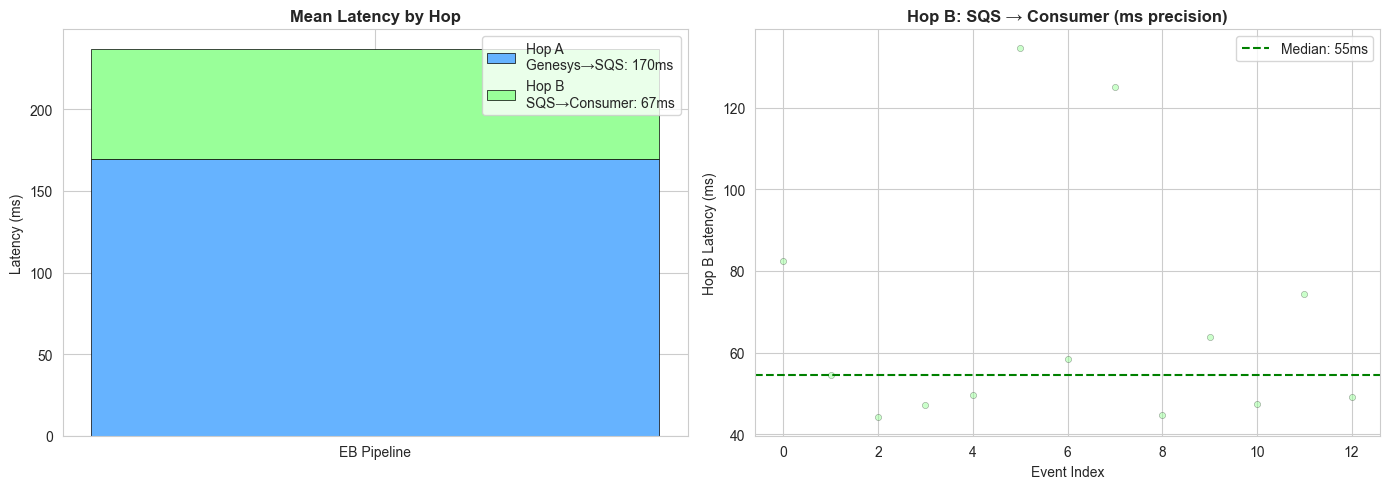

In [13]:
# Chart 4: Stacked bar chart — mean per hop (2-hop)
if not df_hops.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Stacked bar chart — 2 hops
    ax = axes[0]
    hop_means = [
        df_hops["hopA_ms"].mean(),
        df_hops["hopB_ms"].mean(),
    ]
    hop_names = ["Hop A\nGenesys→SQS", "Hop B\nSQS→Consumer"]
    colors = ["#66b3ff", "#99ff99"]
    bottom = 0
    for mean, name, color in zip(hop_means, hop_names, colors):
        ax.bar("EB Pipeline", mean, bottom=bottom, color=color, edgecolor="black",
               linewidth=0.5, label=f"{name}: {mean:.0f}ms")
        bottom += mean
    ax.set_ylabel("Latency (ms)")
    ax.set_title("Mean Latency by Hop", fontsize=12, fontweight="bold")
    ax.legend(loc="upper right")

    # Scatter: Hop B (SQS → Consumer)
    ax = axes[1]
    ax.scatter(range(len(df_hops)), df_hops["hopB_ms"], alpha=0.5, s=20, color="#99ff99",
               edgecolors="black", linewidth=0.3)
    ax.axhline(df_hops["hopB_ms"].median(), color="green", linestyle="--",
               label=f"Median: {df_hops['hopB_ms'].median():.0f}ms")
    ax.set_xlabel("Event Index")
    ax.set_ylabel("Hop B Latency (ms)")
    ax.set_title("Hop B: SQS → Consumer (ms precision)", fontsize=12, fontweight="bold")
    ax.legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hop_analysis.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

---
## Module 8: Matched Pairs Detail Tables

In [ ]:
def print_matched_pairs(df, label):
    """Print matched pairs detail table."""
    if df.empty:
        print(f"\n{label}: No data")
        return
    has_conf = "deepgram_confidence" in df.columns and "genesys_confidence" in df.columns
    width = 136 if has_conf else 120
    print(f"\n{'=' * width}")
    print(f"{label} — MATCHED PAIRS")
    print(f"{'=' * width}")
    header = f"{'Latency':>10}  {'Sim':>5}"
    if has_conf:
        header += f"  {'DG Conf':>7}  {'GN Conf':>7}"
    header += f"  {'Ch':>8}  {'Deepgram Transcript':<35}  {'Genesys Transcript':<35}"
    print(header)
    print("-" * width)
    for _, row in df.iterrows():
        dg_t = row["deepgram_transcript"][:33] + (".." if len(row["deepgram_transcript"]) > 33 else "")
        gn_t = row["genesys_transcript"][:33] + (".." if len(row["genesys_transcript"]) > 33 else "")
        line = f"{row['true_latency_ms']:>8.0f}ms  {row['similarity']:>5.2f}"
        if has_conf:
            line += f"  {row['deepgram_confidence']:>7.3f}  {row['genesys_confidence']:>7.3f}"
        line += f"  {row['channel']:>8}  {dg_t:<35}  {gn_t:<35}"
        print(line)


print_matched_pairs(df_notif, "Notifications API (WebSocket)")
print_matched_pairs(df_eb, "EventBridge (SQS)")

---
## Module 10: Confidence Score Analysis

Compare STT confidence scores across delivery paths. Both Notifications and EventBridge carry the same Genesys r2d2 confidence value; Deepgram Nova-3 reports its own independent confidence. Since all three sources transcribe the same audio, differences reflect the STT engine's self-assessed certainty.

Key questions:
1. Are Deepgram and Genesys/r2d2 confidence scores comparable in magnitude?
2. Do they correlate (high-confidence in one engine → high-confidence in the other)?
3. Do lower-confidence utterances tend to have higher latency?

In [ ]:
def print_confidence_summary(df, label):
    """Print per-path confidence statistics."""
    if df.empty or "deepgram_confidence" not in df.columns:
        print(f"\n{label}: No confidence data")
        return

    dg_conf = df["deepgram_confidence"]
    gn_conf = df["genesys_confidence"]

    print(f"\n{'=' * 70}")
    print(f"{label} — CONFIDENCE SUMMARY")
    print(f"{'=' * 70}")
    print(f"  {'Metric':<25} {'Deepgram':>10} {'Genesys/r2d2':>14}")
    print(f"  {'-' * 50}")
    print(f"  {'Mean':.<25} {dg_conf.mean() * 100:>9.1f}% {gn_conf.mean() * 100:>13.1f}%")
    print(f"  {'Median':.<25} {dg_conf.median() * 100:>9.1f}% {gn_conf.median() * 100:>13.1f}%")
    print(f"  {'Std Dev':.<25} {dg_conf.std() * 100:>9.1f}% {gn_conf.std() * 100:>13.1f}%")
    print(f"  {'Min':.<25} {dg_conf.min() * 100:>9.1f}% {gn_conf.min() * 100:>13.1f}%")
    print(f"  {'Max':.<25} {dg_conf.max() * 100:>9.1f}% {gn_conf.max() * 100:>13.1f}%")
    print(f"  {'N':.<25} {len(dg_conf):>10} {len(gn_conf):>14}")

    # Paired comparison
    mean_diff = (dg_conf - gn_conf).mean()
    higher = "Deepgram" if mean_diff > 0 else "Genesys/r2d2"
    print(f"\n  Paired mean difference (DG - GN): {mean_diff * 100:+.2f}%")
    print(f"  On average, {higher} reports higher confidence.")


print_confidence_summary(df_notif, "Notifications API (WebSocket)")
print_confidence_summary(df_eb, "EventBridge (SQS)")

In [ ]:
# Head-to-head confidence table (reuses compute_stats, displayed as x100 percentages)
def confidence_stats(values):
    """Compute confidence stats (same keys as compute_stats but for 0-1 scores)."""
    if not values:
        return {k: float("nan") for k in ["median", "mean", "min", "max", "std", "n"]}
    s = sorted(values)
    n = len(s)
    return {
        "median": statistics.median(s),
        "mean": statistics.mean(s),
        "min": s[0],
        "max": s[-1],
        "std": statistics.stdev(s) if n >= 2 else 0.0,
        "n": n,
    }


conf_rows = {}
for label, df in [("Notifications", df_notif), ("EventBridge", df_eb)]:
    if df.empty or "deepgram_confidence" not in df.columns:
        continue
    conf_rows[f"{label} — Deepgram"] = confidence_stats(df["deepgram_confidence"].tolist())
    conf_rows[f"{label} — Genesys/r2d2"] = confidence_stats(df["genesys_confidence"].tolist())

if conf_rows:
    print("\n" + "=" * 90)
    print("CONFIDENCE SCORE HEAD-TO-HEAD")
    print("=" * 90)
    header = f"{'Source':<35} {'Median':>8} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'N':>5}"
    print(header)
    print("-" * 90)
    for label, stats in conf_rows.items():
        print(
            f"{label:<35} {stats['median'] * 100:>7.1f}% {stats['mean'] * 100:>7.1f}% "
            f"{stats['std'] * 100:>7.1f}% {stats['min'] * 100:>7.1f}% "
            f"{stats['max'] * 100:>7.1f}% {stats['n']:>5.0f}"
        )
else:
    print("No confidence data available for comparison.")

In [ ]:
# Confidence charts — use df_all (combined Notifications + EventBridge)
if not df_all.empty and "deepgram_confidence" in df_all.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart A: Scatter — Deepgram vs Genesys confidence with y=x identity line
    ax = axes[0]
    dg_c = df_all["deepgram_confidence"] * 100
    gn_c = df_all["genesys_confidence"] * 100
    colors_map = {"Notifications": "steelblue", "EventBridge": "darkorange"}
    for source, color in colors_map.items():
        mask = df_all["source"] == source
        if mask.any():
            ax.scatter(dg_c[mask], gn_c[mask], alpha=0.7, s=50, color=color,
                       edgecolors="black", linewidth=0.3, label=source)
    # Identity line
    lims = [min(dg_c.min(), gn_c.min()) - 2, max(dg_c.max(), gn_c.max()) + 2]
    ax.plot(lims, lims, "k--", alpha=0.3, label="y = x")
    # Pearson r using pandas
    r_val = pd.Series(df_all["deepgram_confidence"].values).corr(
        pd.Series(df_all["genesys_confidence"].values)
    )
    ax.set_xlabel("Deepgram Confidence (%)")
    ax.set_ylabel("Genesys/r2d2 Confidence (%)")
    ax.set_title(f"DG vs GN Confidence (r = {r_val:.3f})", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

    # Chart B: Overlaid histogram — confidence distributions
    ax = axes[1]
    bins = np.linspace(
        min(dg_c.min(), gn_c.min()) - 2,
        max(dg_c.max(), gn_c.max()) + 2,
        25,
    )
    ax.hist(dg_c, bins=bins, alpha=0.6, color="mediumpurple", edgecolor="black",
            linewidth=0.5, label=f"Deepgram (median {dg_c.median():.1f}%)")
    ax.hist(gn_c, bins=bins, alpha=0.6, color="seagreen", edgecolor="black",
            linewidth=0.5, label=f"Genesys (median {gn_c.median():.1f}%)")
    ax.set_xlabel("Confidence (%)")
    ax.set_ylabel("Count")
    ax.set_title("Confidence Distributions", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

    # Chart C: Scatter — Confidence vs Latency (do low-confidence = high latency?)
    ax = axes[2]
    lat = df_all["true_latency_ms"]
    avg_conf = (df_all["deepgram_confidence"] + df_all["genesys_confidence"]) / 2 * 100
    for source, color in colors_map.items():
        mask = df_all["source"] == source
        if mask.any():
            ax.scatter(avg_conf[mask], lat[mask], alpha=0.7, s=50, color=color,
                       edgecolors="black", linewidth=0.3, label=source)
    r_lat = pd.Series(avg_conf.values).corr(pd.Series(lat.values))
    ax.set_xlabel("Avg Confidence (DG+GN)/2 (%)")
    ax.set_ylabel("True Latency (ms)")
    ax.set_title(f"Confidence vs Latency (r = {r_lat:.3f})", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "confidence_analysis.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()
else:
    print("No confidence data available for charts.")

---
## Module 9: Export Results

In [ ]:
# Export CSVs
if notif_results:
    export_csv(notif_results, OUTPUT_DIR / "notif_correlation.csv")
if eb_results:
    export_csv(eb_results, OUTPUT_DIR / "eb_correlation.csv")

# Export head-to-head comparison JSON
comparison = {
    "session_triples": [
        {
            "deepgram": dg.name,
            "notifications": nf.name,
            "eventbridge": eb.name if eb else None,
        }
        for dg, nf, eb in triple_matched
    ],
    "eb_only_pairs": [
        {
            "deepgram": dg.name,
            "eventbridge": eb.name,
        }
        for dg, eb in eb_only_matched
    ],
    "similarity_threshold": SIMILARITY_THRESHOLD,
    "notifications": compute_stats(df_notif["true_latency_ms"].tolist()) if not df_notif.empty else {},
    "eventbridge": compute_stats(df_eb["true_latency_ms"].tolist()) if not df_eb.empty else {},
    "self_reported": compute_stats(sr_latencies_ms) if self_reported_all else {},
    "eb_self_reported": compute_stats(eb_sr_latencies_ms) if eb_self_reported_all else {},
    "deepgram_audio_hook": compute_stats(dg_latencies_ms) if dg_latencies_ms else {},
}

# Add hop analysis if available
if not df_hops.empty:
    comparison["hop_analysis"] = {
        "hopA_genesys_to_sqs": compute_stats(df_hops["hopA_ms"].tolist()),
        "hopB_sqs_to_consumer": compute_stats(df_hops["hopB_ms"].tolist()),
        "total": compute_stats(df_hops["total_ms"].tolist()),
        "note": "ebTime excluded — second-level precision causes systematic negative values.",
    }

# Add confidence analysis if available
conf_export = {}
for label, df_src in [("notifications", df_notif), ("eventbridge", df_eb)]:
    if not df_src.empty and "deepgram_confidence" in df_src.columns:
        conf_export[label] = {
            "deepgram": confidence_stats(df_src["deepgram_confidence"].tolist()),
            "genesys_r2d2": confidence_stats(df_src["genesys_confidence"].tolist()),
        }
if conf_export:
    comparison["confidence"] = conf_export

comparison_path = OUTPUT_DIR / "head_to_head_comparison.json"
comparison_path.write_text(json.dumps(comparison, indent=2, default=float))

# Export summary JSON (same structure as notebook 01)
for label, df_source, filename in [
    ("Notifications", df_notif, "notif_summary.json"),
    ("EventBridge", df_eb, "eb_summary.json"),
]:
    if not df_source.empty:
        summary = {
            "source": label,
            "matched_pairs": len(df_source),
            "latency_ms": compute_stats(df_source["true_latency_ms"].tolist()),
            "mean_similarity": round(df_source["similarity"].mean(), 3),
        }
        if "deepgram_confidence" in df_source.columns:
            summary["confidence"] = {
                "deepgram": confidence_stats(df_source["deepgram_confidence"].tolist()),
                "genesys_r2d2": confidence_stats(df_source["genesys_confidence"].tolist()),
            }
        (OUTPUT_DIR / filename).write_text(json.dumps(summary, indent=2, default=float))

print(f"\nExported to {OUTPUT_DIR}:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}")